In [63]:
import pandas as pd, numpy as np
from scipy.spatial.distance import squareform, pdist, cdist
from sklearn.neighbors import kneighbors_graph, NearestNeighbors
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import shortest_path, connected_components
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, gaussian_kde
from sklearn.decomposition import PCA
import dcor
import itertools
import joblib
import plot_style as ps
import matplotlib.ticker as ticker

In [186]:
LINEAR_COLOUR = "red" # maybe could use import matplotlib.patheffects as pe to outline lines if necessary
ORDINARY_COLOUR = "orange"
DENSITY_COLOUR = "black"
PCA_COLOUR = "blue"
OBSERVED_COLOUR = "green"

colour_map = {
    "density_aware": DENSITY_COLOUR,
    "ordinary_graph": ORDINARY_COLOUR,
    "linear": LINEAR_COLOUR,
    "PCA": PCA_COLOUR,
    "observed": OBSERVED_COLOUR
}

TITLE_FONTSIZE = 18
LABEL_FONTSIZE = 14
TICK_FONTSIZE = 14
LEGEND_FONTSIZE = 14
SUPTITLE_FONTSIZE = 18
GRID_ALPHA = 0.3
LINEWIDTH = 3

plt.rcParams.update({
    "axes.titlesize": TITLE_FONTSIZE,
    "axes.labelsize": LABEL_FONTSIZE,
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
    "legend.fontsize": LEGEND_FONTSIZE,
    "figure.titlesize": SUPTITLE_FONTSIZE,
    "lines.linewidth": LINEWIDTH
})

In [ ]:
def diffusion_map(data, eps, alpha=1, k=4):
    Dsq = squareform(pdist(data)**2)
    Wm = np.exp(-Dsq/eps); q = Wm.sum(1)
    Wa = Wm/np.outer(q**alpha, q**alpha)
    da = Wa.sum(1); Dis = 1.0/np.sqrt(da)
    P = (1.0/da)[:, None] * Wa
    S = Dis[:, None]*Wa*Dis[None, :]                
    w, v = np.linalg.eigh(S)
    idx = np.argsort(w)[::-1]; w, v = w[idx], v[:, idx]
    phi = Dis[:, None]*v                             
    Psi = phi[:, 1:k+1]*w[1:k+1]                     
    return {"evals": w, "Psi": Psi, "phi": phi, "W": Wm, "P": P, "degrees": q, "w":w, "eps": eps, "alpha": alpha}

def reconstruct_path(pred, start, end):
    path = [end]; current = end
    while current != start:
        current = pred[start, current]
        if current == -9999: return None
        path.append(current)
    return path[::-1]

def graph_degree_density(Psi, h):
    Dsq = squareform(pdist(Psi)**2)
    rho = np.exp(-Dsq/h).sum(1)
    scale = rho.mean(); rho /= scale
    rho = np.maximum(rho, 1e-6)
    return rho, -np.log(rho), scale

def density_and_bandwidth(Psi, multiplier=0.1):
    N = Psi.shape[0]
    median_Dsq = np.median(squareform(pdist(Psi)**2)[np.triu_indices(N,1)])
    h = multiplier * median_Dsq
    return h, median_Dsq, graph_degree_density(Psi, h)

def density_aware_cost(A_dist_sym, V, beta):
    rows, cols = A_dist_sym.nonzero()
    base = np.asarray(A_dist_sym[rows, cols]).ravel()
    costs = base*np.exp(beta*(V[rows]+V[cols])/2)
    return csr_matrix((costs, (rows, cols)), shape=A_dist_sym.shape)

def graph_path(A_dist_sym, beta, V, start, end):
    A = density_aware_cost(A_dist_sym, V, beta)
    _, pred = shortest_path(A, directed=False, return_predecessors=True)
    return reconstruct_path(pred, start, end)

def latent_density_at_points(gamma, Psi, h, scale):
    Dsq_query = cdist(gamma, Psi, metric="sqeuclidean")
    rho_query = np.exp(-Dsq_query / h).sum(axis=1)
    rho_query /= scale
    rho_query_floor = np.maximum(rho_query, 1e-6)
    V_query = -np.log(rho_query_floor)
    return rho_query_floor, V_query

def loo_graph_density(indices, Psi, h, scale):
    rho_out = np.zeros(len(indices))
    V_out = np.zeros(len(indices))
    for p, idx in enumerate(indices):
        mask = np.ones(len(Psi), dtype=bool)
        mask[idx] = False
        rho_i, V_i = latent_density_at_points(Psi[idx:idx+1], Psi[mask], h, scale)
        rho_out[p] = rho_i[0]; V_out[p] = V_i[0]
    return rho_out, V_out

def local_neighbourhood_lifting(Z, Psi, gamma, start_idx, end_idx, m=27, tau=0.2):
    nn = NearestNeighbors(n_neighbors=m); nn.fit(Psi)
    distances, indices = nn.kneighbors(gamma)
    a = np.exp(-distances**2/tau) / np.sum(np.exp(-distances**2 / tau), axis=1, keepdims=True)
    points = Z[indices, :]; z_hat = np.sum(a[:, :, None] * points, axis=1)
    z_hat[0], z_hat[-1] = Z[start_idx], Z[end_idx]
    return z_hat

def linear_path(Psi, start_idx, end_idx, n_grid=10):
    return np.linspace(Psi[start_idx], Psi[end_idx], num=n_grid)


In [241]:
K_GRAPH = 15
BETA = 1.5
N_DIFFUSION_COORDS = 4
EPS_DIFFUSION = 3
M_LIFT = 16

df = pd.read_parquet("./datasets/joint_df_quantile.parquet")
dates = df.index; variables = df.columns[:-1]
Z = df.to_numpy()[:, :-1]; N = Z.shape[0]

obs_df = pd.read_parquet("./datasets/observed_df.parquet").loc[dates]
Z_real = obs_df[variables].to_numpy()

diff = diffusion_map(Z, EPS_DIFFUSION, k=N_DIFFUSION_COORDS)
Psi = diff["Psi"]; P = diff["P"]

h_dens, med_Dsq, (rho, V, scale) = density_and_bandwidth(Psi)

endpoint_pairs = {"1977 benign -> 1982 Recession Trough": ("1977-01-01", "1982-07-01"),
                  "2006 benign -> 2008 GFC": ("2006-03-01", "2008-10-01"),
                  "2019 benign -> 2020 COVID": ("2019-07-01", "2020-04-01"), 
                  "2019 benign -> 2022 Monetary Tightening": ("2019-04-01", "2022-04-01")}
pairs = {name: (dates.get_loc(pair[0]), dates.get_loc(pair[1])) for name, pair in endpoint_pairs.items()}

A_dist = kneighbors_graph(Psi, n_neighbors=K_GRAPH, mode="distance", include_self=False)
A_dist_sym = A_dist.maximum(A_dist.T)

# Markov Bridges

This section explores how we generate multiple paths along our manifold using the learned diffusion-map transition matrix $P$, conditioning on $X_0=S$ and $X_T=E$.

Suppose in a simple example we want to find the distribution of a path from $S$ to $E$ with ten steps, so the unknowns are then $X_1, X_2, \ldots, X_9$. We define $$h_t(i) = \text{Pr}(X_T=E | X_t=i),$$ so for example $h_7(i) = (P^3)_{iE}$ ~ the probability of node $i$ landing on node $E$ after the remaining 3 steps of the random walk. The vectors $h_t$ tell us the distribution of all our points at each time step, so the problem boils down to computing $h_t$.

For this, we can simply work backwards. We know that 
$$
h_T(i) = 
\begin{cases}
1 & \text{if } i=E \\
0 & \text{if } i\ne E
\end{cases},
$$
then $h_{T-1} = Ph_T, \ h_{T-2} = Ph_{T-1}, \ldots$

As a $2\times2$ example, let 
$$P =
\begin{pmatrix}
P_{ii} & P_{ij} \\
P_{ji} & P_{jj}
\end{pmatrix},
$$
then $h_T = [1\ 0]^\top$ and 
$$h_{T-1} = Ph_T = 
\begin{pmatrix}
P_{ii} \\
P_{ji}
\end{pmatrix}.
$$

We can further impose that the sampled bridge paths avoid low density regions by modifying the probabliliy matrix as follows:
$$
\bar P_{ij} \propto P_{ij}\exp(-\alpha V_j),
$$
where $\alpha$ controls the strength of sparsity avoidance.

In [242]:
def compute_markov_bridge(P, s, e, T):
    P = np.asarray(P, dtype=float); N = P.shape[0]
    if P.shape != (N, N): raise ValueError("P must be square.")
    if not np.allclose(P.sum(axis=1), 1.0, atol=1e-10): raise ValueError("Rows of P must sum to 1.")
    h = np.zeros((T + 1, N)); h[T, e] = 1.0
    for t in range(T - 1, -1, -1): 
        h[t] = P @ h[t + 1]
    forward = np.zeros((T + 1, N)); forward[0, s] = 1.0
    for t in range(T):
        forward[t + 1] = forward[t] @ P
    endpoint_prob = forward[T, e]
    if endpoint_prob <= 0: raise ValueError(f"Node e cannot be reached from s in exactly {T} steps.")
    marginals = forward * h / endpoint_prob
    marginals = np.clip(marginals, 0.0, None)
    marginals /= marginals.sum(axis=1, keepdims=True)

    return {"h": h, "forward": forward, "marginals": marginals, "endpoint_prob": endpoint_prob}

def sample_markov_bridges(P, h, s, e, n_paths=10_000, seed=42):
    P = np.asarray(P, dtype=float)
    T = h.shape[0] - 1; N = P.shape[0]
    rng = np.random.default_rng(seed)
    paths = np.empty((n_paths, T + 1), dtype=int)
    paths[:, 0] = s
    current = np.full(n_paths, s, dtype=int)
    for t in range(T):
        next_nodes = np.empty(n_paths, dtype=int)
        # Group simulations currently occupying the same node
        for i in np.unique(current):
            mask = current == i
            weights = P[i] * h[t + 1]
            total = weights.sum()
            if total <= 0: raise RuntimeError(f"No valid bridge transition from node {i} at step {t}.")
            probs = weights / total
            next_nodes[mask] = rng.choice(N, size=mask.sum(), p=probs)
        paths[:, t + 1] = next_nodes; current = next_nodes

    if not np.all(paths[:, -1] == e): raise RuntimeError("Bridge endpoint condition failed.")
    return paths

### Analysis of bridge paths in diffusion space

In [243]:
def weighted_mean_density(coords, density):
    coords = np.asarray(coords); density = np.asarray(density)
    lengths = np.linalg.norm(np.diff(coords, axis=1), axis=2)
    edge_density = (density[:, 1:] + density[:, :-1]) / 2

    return np.sum(edge_density * lengths, axis=1) / np.sum(lengths, axis=1)

def total_turning_angle(coords):
    coords = np.asarray(coords)
    single_path = coords.ndim == 2
    if single_path: coords = coords[None, :, :]
    angles = np.zeros(len(coords))
    for m, path in enumerate(coords):
        keep = np.r_[True, np.any(np.diff(path, axis=0) != 0, axis=1)]
        path = path[keep]
        if len(path) < 3:
            angles[m] = 0.0
            continue
        d = np.diff(path, axis=0)
        u = d / np.linalg.norm(d, axis=1, keepdims=True)
        dot_products = np.sum(u[:-1] * u[1:], axis=1)
        theta = np.arccos(np.clip(dot_products, -1.0, 1.0))
        angles[m] = theta.sum()
    return angles[0] if single_path else angles


def loo_graph_density(indices, Psi, h, scale):
    indices = np.asarray(indices, dtype=int); original_shape = indices.shape
    flat_indices = indices.ravel(); unique_indices = np.unique(flat_indices)
    rho_lookup = {}
    for idx in unique_indices:
        mask = np.ones(len(Psi), dtype=bool); mask[idx] = False
        rho_i, _ = latent_density_at_points(Psi[idx:idx+1], Psi[mask], h, scale)
        rho_lookup[idx] = rho_i[0]
    rho_out = np.array([rho_lookup[idx] for idx in flat_indices])

    return rho_out.reshape(original_shape)


def generate_density_aware_bridge_paths(P, start_idx, end_idx, alpha, V, T=8, n_paths=10_000):
    density_weight = np.exp(-alpha * V)
    P_da = P * density_weight[None, :] 
    q_da = P_da.sum(axis=1)
    P_da = P_da / q_da[:, None]
    bridge_da = compute_markov_bridge(P_da, start_idx, end_idx, T)
    bridge_paths_da = sample_markov_bridges(P_da, bridge_da["h"], start_idx, end_idx, n_paths=n_paths, seed=42)
    return bridge_paths_da, bridge_da

def calculate_path_metrics(paths, Psi, rho, V, beta):
    
    # NEED TO IMPLEMENT LOO DENSITY AND WEIGHTED MEAN DENSITY TO BE CONSISTENT

    paths = np.asarray(paths, dtype=int)
    single_path = paths.ndim == 1
    if single_path: paths = paths[None, :]
    coords = Psi[paths]
    step_lengths = np.linalg.norm(np.diff(coords, axis=1), axis=2)
    path_density = loo_graph_density(paths, Psi, h_dens, scale)
    path_V = V[paths]
    weighted_edges = (step_lengths * np.exp(beta * (path_V[:, :-1] + path_V[:, 1:]) / 2))

    interior_path_density = path_density[:, 1:-1]
    
    results = pd.DataFrame({
        "min_density": interior_path_density.min(axis=1),
        "weighted_mean_density": weighted_mean_density(coords, path_density),
        "path_length": step_lengths.sum(axis=1),
        "total_turning_angle": total_turning_angle(coords),
        "density_aware_cost": weighted_edges.sum(axis=1)})

    if single_path: return results.iloc[0]
    return results

### Density aware bridge statistics for different levels of $\alpha$

In [244]:
alphas = [0.0, 0.5, 1.0, 1.5, 3, 10]

Event: 1977 benign -> 1982 Recession Trough


min_density                     weighted_mean_density            \
             mean    median       std                  mean    median   
alpha                                                                   
0.0      0.603229  0.605897  0.299702              0.891398  0.912065   
0.5      0.714380  0.715399  0.272615              0.952250  0.970642   
1.0      0.791051  0.813685  0.250606              0.990378  1.006123   
1.5      0.848971  0.868487  0.230060              1.018107  1.031346   
3.0      0.970186  1.005568  0.191974              1.070443  1.080960   
10.0     1.188763  1.193458  0.108461              1.155135  1.159947   

                path_length                     total_turning_angle            \
            std        mean    median       std                mean    median   
alpha                                                                           
0.0    0.155447    1.182839  1.155122  0.249236            7.577944  7.628591   
0.5    0.128003    1.118794  1.099924  0.215960            7.551013  7.601767   
1.0    0.109852    1.081932  1.063869  0.201003            7.512136  7.570774   
1.5    0.096481    1.053456  1.038766  0.186408            7.505953  7.544617   
3.0    0.074338    0.992871  0.980120  0.162503            7.446644  7.518395   
10.0   0.038687    0.871137  0.864240  0.120345            7.356437  7.434539   

                 
            std  
alpha            
0.0    1.153570  
0.5    1.149860  
1.0    1.146236  
1.5    1.146914  
3.0    1.135624  
10.0   1.165190


Results for discrete density awaare path:


min_density              1.172600
weighted_mean_density    1.120337
path_length              0.401877
total_turning_angle      3.810576
density_aware_cost       0.365544
Name: 0, dtype: float64

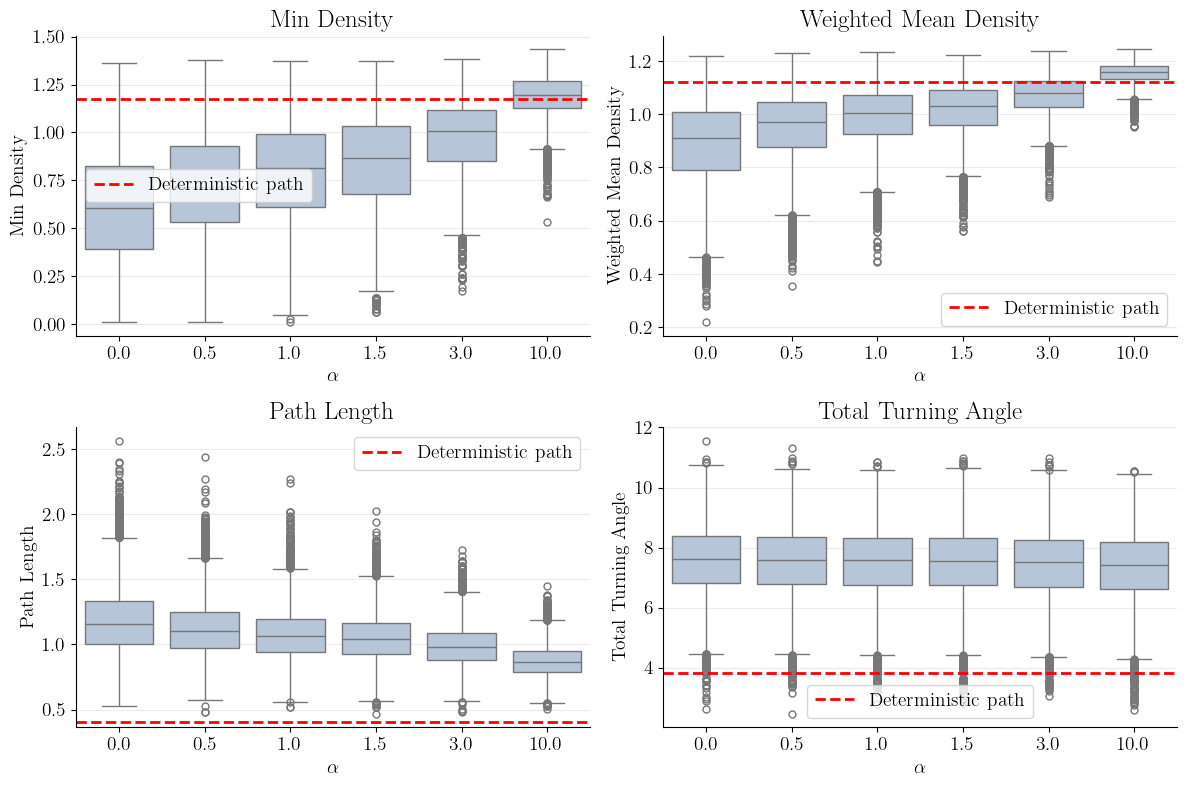

In [246]:
event = list(pairs.keys())[0]
start_idx, end_idx = pairs[event]
print(f'Event: {event}')
density_path = graph_path(A_dist_sym, BETA, V, start_idx, end_idx)
T = len(density_path) - 1

metrics = ["min_density", "weighted_mean_density", "path_length", "total_turning_angle"]

bridge_metric_records = []

for alpha in alphas:
    bridge_paths, _ = generate_density_aware_bridge_paths(P, start_idx, end_idx, alpha, V, T=T, n_paths=10_000)
    bridge_metrics = calculate_path_metrics(bridge_paths, Psi, rho, V, BETA)
    bridge_metrics["alpha"] = alpha
    bridge_metric_records.append(bridge_metrics)

bridge_metric_df = pd.concat(bridge_metric_records, ignore_index=True)

summary = (bridge_metric_df.groupby("alpha")[metrics].agg(["mean", "median", "std"]))

display(summary)

density_path_metrics = calculate_path_metrics(density_path, Psi, rho, V, BETA)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), squeeze=False)
axes = axes.ravel()

for ax, metric in zip(axes, metrics):
    sns.boxplot(data=bridge_metric_df, x="alpha", y=metric, ax=ax, color="lightsteelblue")
    ax.axhline(float(density_path_metrics[metric]), ls="--", c="r", lw=2, label="Deterministic path")
    ax.set_title(metric.replace("_", " ").title())
    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel(metric.replace("_", " ").title())
    ax.legend()


print("\nResults for discrete density awaare path:")
display(density_path_metrics)

plt.tight_layout()
plt.savefig("./figures/markov_diss_metrics_trough.pdf")
plt.show()

These results show that the density penalty does a similar thing for the bridges as it does for the denstiy-aware graph paths; it increases the min and mean density. However, it actually decreases the average path length, because the paths now are less likely to make long jumps to low density nodes.


Event: 1977 benign -> 1982 Recession Trough


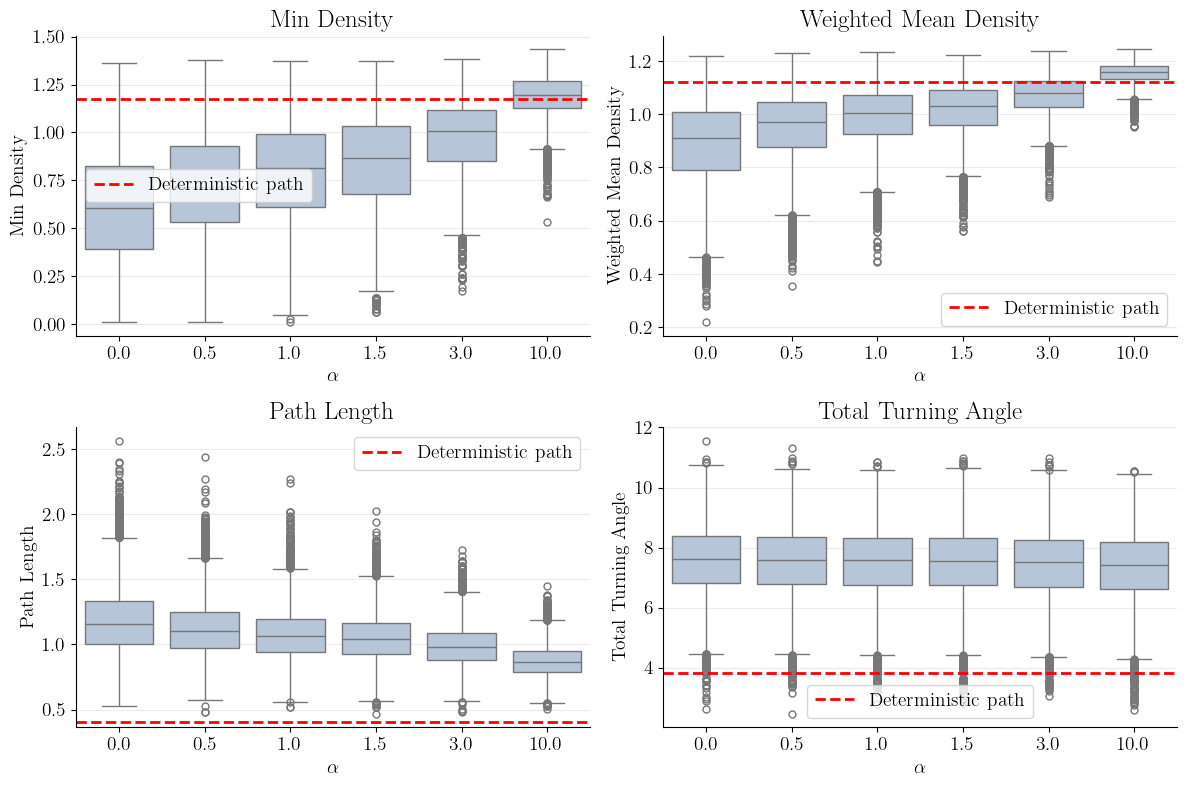

Event: 2006 benign -> 2008 GFC


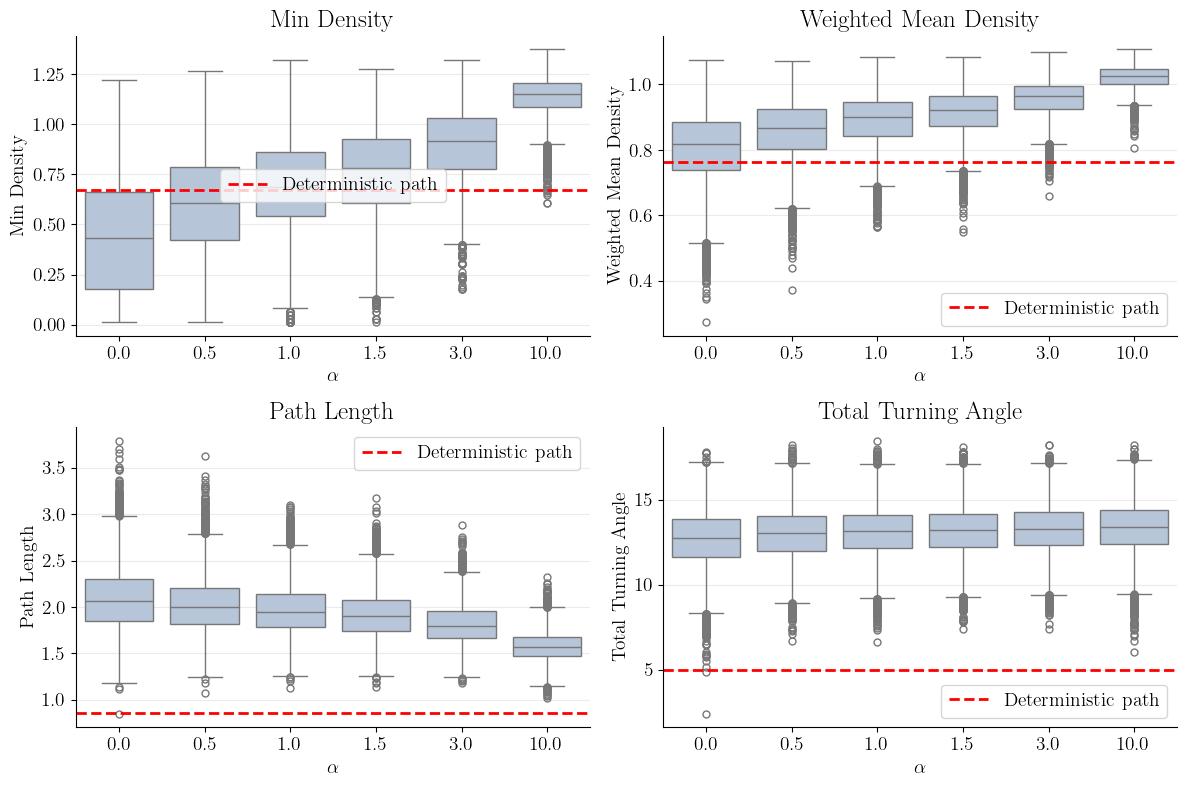

Event: 2019 benign -> 2020 COVID


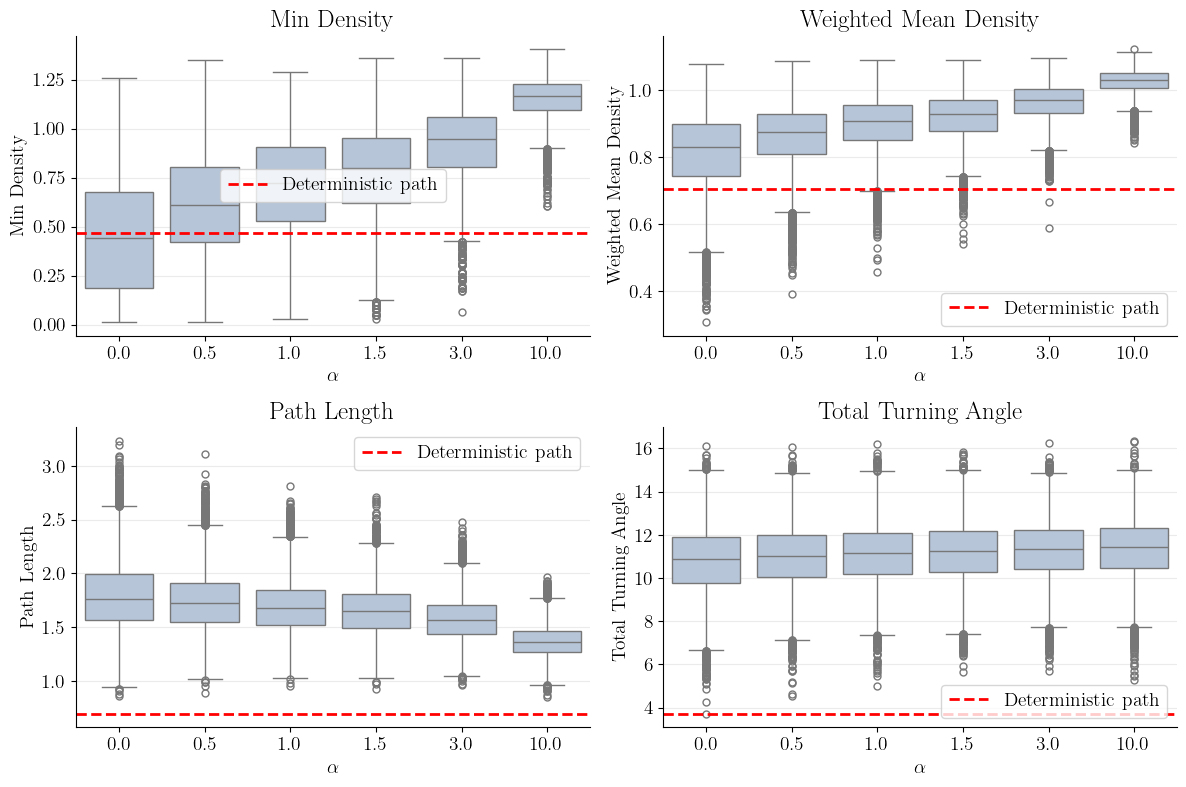

Event: 2019 benign -> 2022 Monetary Tightening


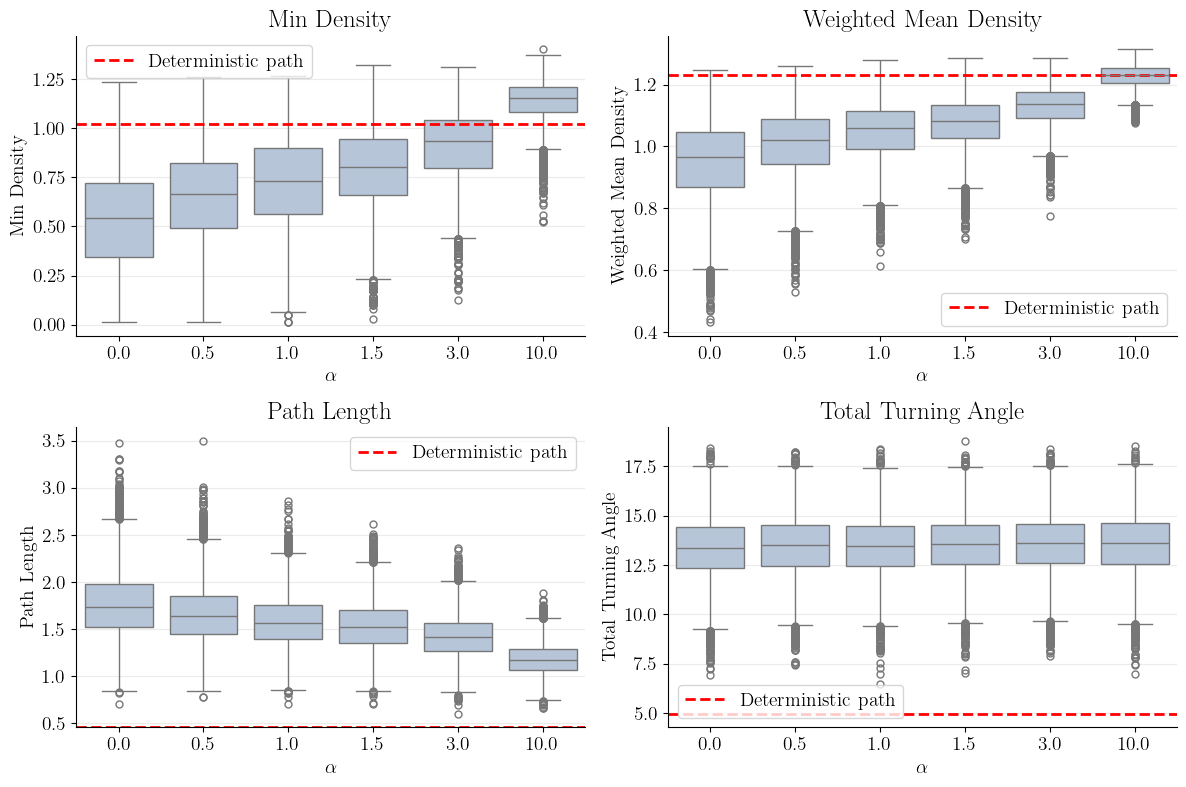

In [236]:
for event, (start_idx, end_idx) in pairs.items():
    print(f'Event: {event}')

    density_path = graph_path(A_dist_sym, BETA, V, start_idx, end_idx)
    T = len(density_path) - 1

    metrics = ["min_density", "weighted_mean_density", "path_length", "total_turning_angle"]

    bridge_metric_records = []

    for alpha in alphas:
        bridge_paths, _ = generate_density_aware_bridge_paths(P, start_idx, end_idx, alpha, V, T=T, n_paths=10_000)
        bridge_metrics = calculate_path_metrics(bridge_paths, Psi, rho, V, BETA)
        bridge_metrics["alpha"] = alpha
        bridge_metric_records.append(bridge_metrics)

    bridge_metric_df = pd.concat(bridge_metric_records, ignore_index=True)

    summary = (bridge_metric_df.groupby("alpha")[metrics].agg(["mean", "median", "std"]))

    density_path_metrics = calculate_path_metrics(density_path, Psi, rho, V, BETA)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), squeeze=False)
    axes = axes.ravel()

    for ax, metric in zip(axes, metrics):
        sns.boxplot(data=bridge_metric_df, x="alpha", y=metric, ax=ax, color="lightsteelblue")
        ax.axhline(float(density_path_metrics[metric]), ls="--", c="r", lw=2, label="Deterministic path")
        ax.set_title(metric.replace("_", " ").title())
        ax.set_xlabel(r"$\alpha$")
        ax.set_ylabel(metric.replace("_", " ").title())
        ax.legend()

    plt.tight_layout()
    plt.show()


### How concentrated is the bridge distribtuion?
We can calculate entropy using the bridge marginals $\mu_k(i)$ as:
$$
H_k = -\sum_{i=1}^N \mu_k(i)\log(\mu_k(i)),
$$
where $N$ is the number of observations.

Low $H_k$ means that the bridge is concentrated around a small number of states, whereas high $H_k$ means that many different routes are possible.

We can also compare $H_k^{0}$ to $H_k^{(\alpha)}$ to see the impact of $\alpha$

In [154]:
def entropy(bridge_marginals):
    p = np.asarray(bridge_marginals)
    log_p = np.zeros_like(p) # 0log(0) := 0
    mask = p > 0
    log_p[mask] = np.log(p[mask])

    return -np.sum(p * log_p, axis=1)

### How close is the bridge distribution to the deterministic density-aware path?
Because we have the same number of bridge jumps as graph path jumps, we can calculate 
$$
d_t = \mathbb{E}[\|\Psi(X_t) - \Psi(\Gamma_t^\beta)\|].
$$

We have the marginals $\mu_i(t)$, so we can calcualte this as
$$
d_t = \sum_{i=1}^N\mu_t(i)\|\psi_i - \psi_{\Gamma_t^\beta}\|.
$$

We can also calculate the probability mass lying within a specific radius of the deterministic density-aware path
$$
\Pr(\|\Psi(X_t) - \Psi(\Gamma_t^\beta)\| \le r),
$$
using
$$
d_{m,t} = \|\Psi(X^{(m)}_t) - \Psi(\Gamma_t^\beta)\|,
$$
and then
$$
\Pr(d_t < r) \approx \frac{1}{M}\sum_{m=1}^M\mathbb{1}\{d_{m,t}<r\},
$$
where $M$ is the number of sampled bridges.

In [155]:
def expected_distance(Psi, density_aware_coords, bridge_marginals):
    dt = np.zeros(len(density_aware_coords))
    for t in range(len(density_aware_coords)):
        distances = np.linalg.norm(Psi - density_aware_coords[t], axis=1)
        dt[t] = np.sum(bridge_marginals[t] * distances)
    return dt

def probability_mass(density_aware_coords, bridge_coords, r):
    distances = np.linalg.norm(bridge_coords - density_aware_coords[None, :, :], axis=2)
    return (distances < r).mean(axis=0)


def probability_mass_exact(Psi, density_aware_coords, bridge_marginals, r):
    probs = np.zeros(len(density_aware_coords))
    for t in range(len(density_aware_coords)):
        distances = np.linalg.norm(Psi - density_aware_coords[t], axis=1)
        probs[t] = np.sum(bridge_marginals[t][distances <= r])
    return probs


In [156]:
r_bridge = np.median(A_dist_sym.data)
print(f"Bridge neighbourhood radius: {r_bridge:.4f}")

Bridge neighbourhood radius: 0.0725


In [237]:
all_path_summaries = []
all_bridge_diagnostics = []
deterministic_summaries = []

n_paths_all = 10_000

for event, (start_idx, end_idx) in pairs.items():

    # Deterministic density-aware graph path
    density_path = graph_path(A_dist_sym, BETA, V, start_idx, end_idx)
    density_coords = Psi[density_path]
    T = len(density_path) - 1

    # Store deterministic benchmark once per event
    deterministic_metrics = calculate_path_metrics(density_path, Psi, rho, V, BETA)
    deterministic_summaries.append({"event": event, **deterministic_metrics.to_dict()})

    for alpha in alphas:

        bridge_paths, bridge = generate_density_aware_bridge_paths(P, start_idx, end_idx, alpha, V, T=T, n_paths=n_paths_all)

        # Individual path metrics
        path_metrics = calculate_path_metrics(bridge_paths, Psi, rho, V, BETA)

        all_path_summaries.append({"event": event, "alpha": alpha,
                                   "min_density_median": path_metrics["min_density"].median(), 
                                   "min_density_q10": path_metrics["min_density"].quantile(0.10),
                                   "min_density_q90": path_metrics["min_density"].quantile(0.90),

                                   "weighted_mean_density_median": path_metrics["weighted_mean_density"].median(),
                                   "weighted_mean_density_q10": path_metrics["weighted_mean_density"].quantile(0.10),
                                   "weighted_mean_density_q90": path_metrics["weighted_mean_density"].quantile(0.90),

                                   "path_length_median": path_metrics["path_length"].median(),
                                   "path_length_q10": path_metrics["path_length"].quantile(0.10),
                                   "path_length_q90": path_metrics["path_length"].quantile(0.90),

                                   "turing_angle_median": path_metrics["total_turning_angle"].median(),
                                   "turning_angle_q10": path_metrics["total_turning_angle"].quantile(0.10),
                                   "turning_angle_q90": path_metrics["total_turning_angle"].quantile(0.90)})

        # Distribution metrics
        marginals = bridge["marginals"]
        H = entropy(marginals)
        d = expected_distance(Psi, density_coords, marginals)
        p_close = probability_mass_exact(Psi, density_coords, marginals, r_bridge)

        interior = slice(1, -1)

        all_bridge_diagnostics.append({"event": event, "alpha": alpha,
                                       "mean_entropy": H[interior].mean(),
                                       "max_entropy": H[interior].max(),
                                       "mean_expected_distance": d[interior].mean(), 
                                       "max_expected_distance": d[interior].max(),
                                       "mean_probability_near_path": p_close[interior].mean(), 
                                       "min_probability_near_path": p_close[interior].min()})


path_summary_df = pd.DataFrame(all_path_summaries)
bridge_diagnostic_df = pd.DataFrame(all_bridge_diagnostics)
deterministic_summary_df = pd.DataFrame(deterministic_summaries)

In [238]:
 # display(path_summary_df[["event", "alpha", "min_density_median", "weighted_mean_density_median", "path_length_median"]].round(4))

In [239]:
# display(bridge_diagnostic_df[["event", "alpha", "mean_entropy", "mean_expected_distance", "mean_probability_near_path"]].round(4))

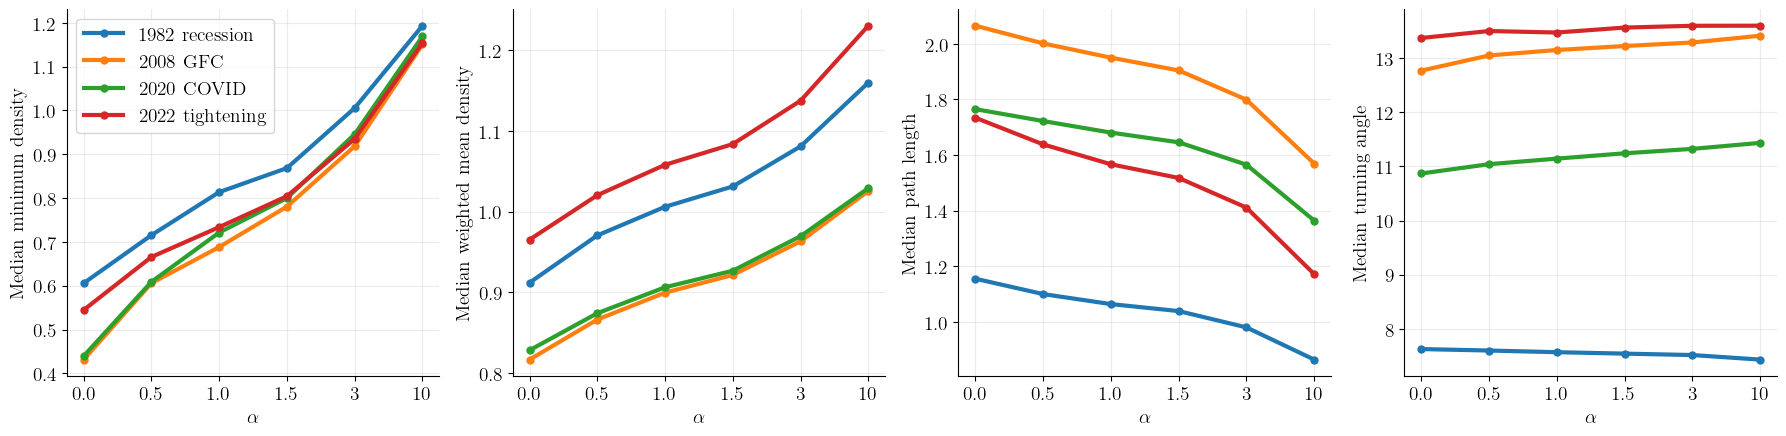

In [240]:
event_short = {
    "1977 benign -> 1982 Recession Trough": "1982 recession",
    "2006 benign -> 2008 GFC": "2008 GFC",
    "2019 benign -> 2020 COVID": "2020 COVID",
    "2019 benign -> 2022 Monetary Tightening": "2022 tightening",
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

plot_metrics = [
    ("min_density_median", "Median minimum density"),
    ("weighted_mean_density_median", "Median weighted mean density"),
    ("path_length_median", "Median path length"),
    ("turing_angle_median", "Median turning angle")
]

x = np.arange(len(alphas))

for ax, (metric, ylabel) in zip(axes, plot_metrics):
    for event in pairs:
        tmp = (path_summary_df[path_summary_df["event"] == event].set_index("alpha").loc[alphas])
        ax.plot(x, tmp[metric], marker="o", label=event_short[event])
    ax.set_xticks(x); ax.set_xticklabels(alphas)
    ax.set_xlabel(r"$\alpha$"); ax.set_ylabel(ylabel)

axes[0].legend()

plt.tight_layout()
plt.show()

In [185]:
diagnostics = {"mean_entropy": "Mean interior entropy",
               "mean_expected_distance": "Mean distance to deterministic path",
               "mean_probability_near_path": "Mean probability near deterministic path"}

def plot_metric(df, metric, figsize=(6,4), save=None):
    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(alphas))

    for event in pairs:
        tmp = (df[df["event"] == event].set_index("alpha").loc[alphas])

        ax.plot(x, tmp[metric], marker="o", label=event_short[event])

    ax.set_xticks(x); ax.set_xticklabels(alphas)
    ax.set_xlabel(r"$\alpha$");ax.set_ylabel(diagnostics[metric])
    ax.legend()

    plt.tight_layout()
    if save is not None:
        if save.split(".")[-1] == "pdf":
            plt.savefig(save)
        else:
            plt.savefig(save, dpi=300, bbox_inches="tight")
    plt.show()

{'mean_entropy': 'Mean interior entropy', 'mean_expected_distance': 'Mean distance to deterministic path', 'mean_probability_near_path': 'Mean probability near deterministic path'}
mean_expected_distance


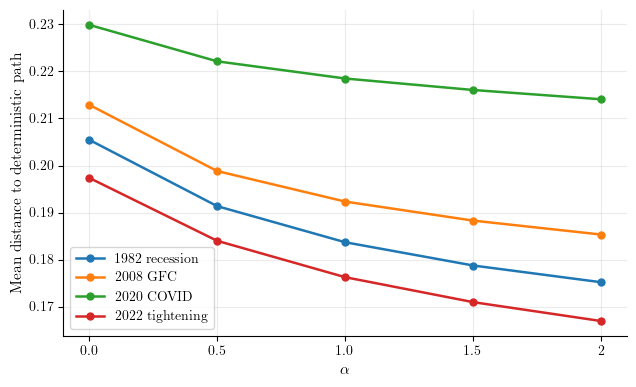

In [184]:
plot_metric(bridge_diagnostic_df, "mean_expected_distance", figsize=ps.FIG_SINGLE_WD, save="./figures/markov_distance_vs_alpha.pdf")

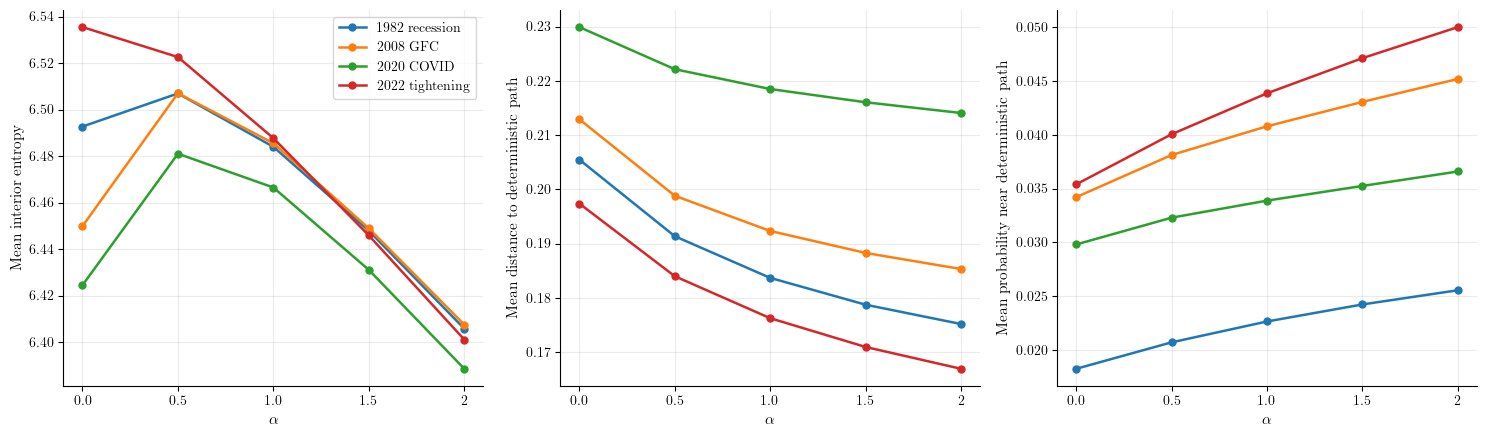

In [163]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

diagnostics = [
    ("mean_entropy", "Mean interior entropy"),
    ("mean_expected_distance",
     "Mean distance to deterministic path"),
    ("mean_probability_near_path",
     "Mean probability near deterministic path"),
]

x = np.arange(len(alphas))

for ax, (metric, ylabel) in zip(axes, diagnostics):

    for event in pairs:
        tmp = (bridge_diagnostic_df[bridge_diagnostic_df["event"] == event].set_index("alpha").loc[alphas])

        ax.plot(x, tmp[metric], marker="o", label=event_short[event])

    ax.set_xticks(x); ax.set_xticklabels(alphas)
    ax.set_xlabel(r"$\alpha$");ax.set_ylabel(ylabel)

axes[0].legend()

plt.tight_layout()
plt.show()

No idea why the probability of being near the density aware path drops off for high alpha in the 1982 recession event. This could be because of a bimodal distribution? 

### "Confidence intervals" for lifted paths

In [164]:
lifted_path_records = []

for event, (start_idx, end_idx) in pairs.items():
    # Observed path
    quantile_path = Z[start_idx:end_idx+1]
    real_path = Z_real[start_idx:end_idx+1]
    
    density_path = graph_path(A_dist_sym, BETA, V, start_idx, end_idx)
    T = len(density_path) - 1

    # normal bridge
    bridge = compute_markov_bridge(P, start_idx, end_idx, T)
    bridge_paths = sample_markov_bridges(P, bridge["h"], start_idx, end_idx, n_paths=10_000, seed=42)
    Z_bridge_quantile = Z[bridge_paths]
    Z_bridge_real = Z_real[bridge_paths]

    # density-aware bridge
    alpha = 1.5
    density_weight = np.exp(-alpha * V)
    P_da = P * density_weight[None, :] 
    q_da = P_da.sum(axis=1)
    P_da = P_da / q_da[:, None]
    bridge_da = compute_markov_bridge(P_da, start_idx, end_idx, T)
    bridge_paths_da = sample_markov_bridges(P_da, bridge_da["h"], start_idx, end_idx, n_paths=10_000, seed=42)
    Z_bridge_quantile_da = Z[bridge_paths_da]
    Z_bridge_real_da = Z_real[bridge_paths_da]

    # Linear lift using LNL
    gamma = linear_path(Psi, start_idx, end_idx, T+1)
    rho_lin, V_lin = latent_density_at_points(gamma, Psi, h_dens, scale)
    Z_lin_quantile = local_neighbourhood_lifting(Z, Psi, gamma, start_idx, end_idx, m=M_LIFT, tau=med_Dsq)
    Z_lin_real = local_neighbourhood_lifting(Z_real, Psi, gamma, start_idx, end_idx, m=M_LIFT, tau=med_Dsq)

    lifted_path_records.append({"event": event, "path_type": "linear", "Z_lift_quantile": Z_lin_quantile, "Z_lift_real": Z_lin_real})
    lifted_path_records.append({"event": event, "path_type": "density_aware", "Z_lift_quantile": Z[density_path], "Z_lift_real": Z_real[density_path]})
    lifted_path_records.append({"event": event, "path_type": "observed", "Z_lift_quantile": quantile_path, "Z_lift_real": real_path})
    lifted_path_records.append({"event": event, "path_type": "bridge_paths", "Z_lift_quantile": Z_bridge_quantile, "Z_lift_real": Z_bridge_real})
    lifted_path_records.append({"event": event, "path_type": "density_aware_bridge_paths", "Z_lift_quantile": Z_bridge_quantile_da, "Z_lift_real": Z_bridge_real_da})

In [165]:
def plot_bridge_paths(Z_paths, var_idx, quantile=95, plot_paths=False, steps=None, ax=None):
    paths = Z_paths[:, :, var_idx]

    median = np.median(paths, axis=0)
    lq = 0.5 - quantile/200; uq = 0.5 + quantile/200
    lower = np.quantile(paths, lq, axis=0)
    upper = np.quantile(paths, uq, axis=0)

    if steps is None:
        steps = np.arange(paths.shape[1])
    if ax is None:
        fig, ax = plt.subplots(figsize=(8,5))

    if plot_paths:
        for i in range(0, 100):
            ax.plot(steps, paths[i], alpha=0.05)

    # 95% pointwise bridge interval
    ax.fill_between(steps, lower, upper, alpha=0.25, label="95% bridge interval")
    ax.plot(steps, median, linewidth=2.5, label="Median bridge path")

In [166]:
event_variables = {
    "1977 benign -> 1982 Recession Trough": ["FEDFUNDS", "UNRATE"],
    "2006 benign -> 2008 GFC": ["HOUST", "BAAFFM"],
    "2019 benign -> 2020 COVID": ["CLAIMSx", "VIXCLSx"],
    "2019 benign -> 2022 Monetary Tightening": ["CPIAUCSL", "FEDFUNDS"],
}

event_variables = {
    "1977 benign -> 1982 Recession Trough": ["FEDFUNDS", "UNRATE"],
    "2006 benign -> 2008 GFC": ["FEDFUNDS", "UNRATE"],
    "2019 benign -> 2020 COVID": ["FEDFUNDS", "UNRATE"],
    "2019 benign -> 2022 Monetary Tightening": ["FEDFUNDS", "UNRATE"],
}

transformed_variable_ylabels = {
    "UNRATE": "Unemployment rate (\\%)",
    "HOUST": "Log housing starts",
    "S&P 500": "Monthly log change in S\\&P 500",
    "FEDFUNDS": "Monthly change in federal funds rate",
    "CPIAUCSL": "Second log difference of CPI",
}

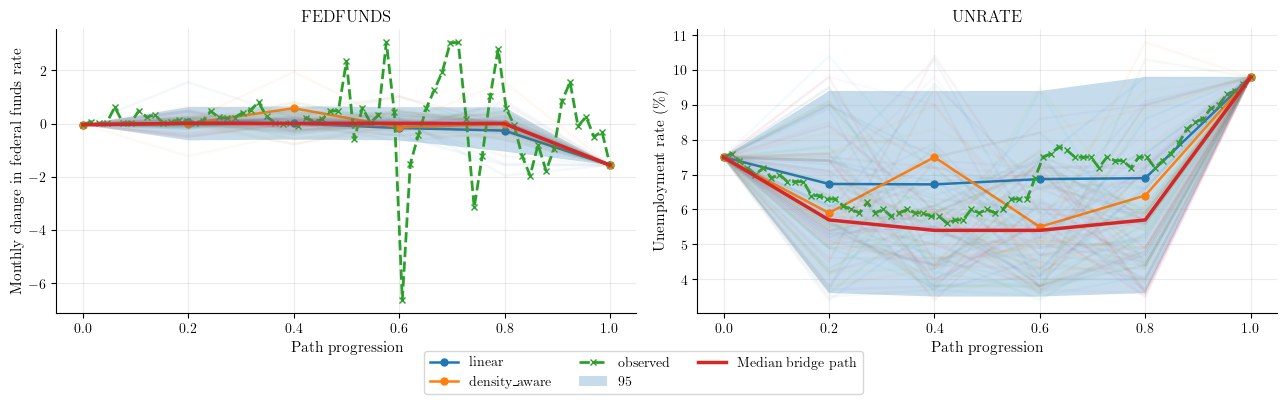

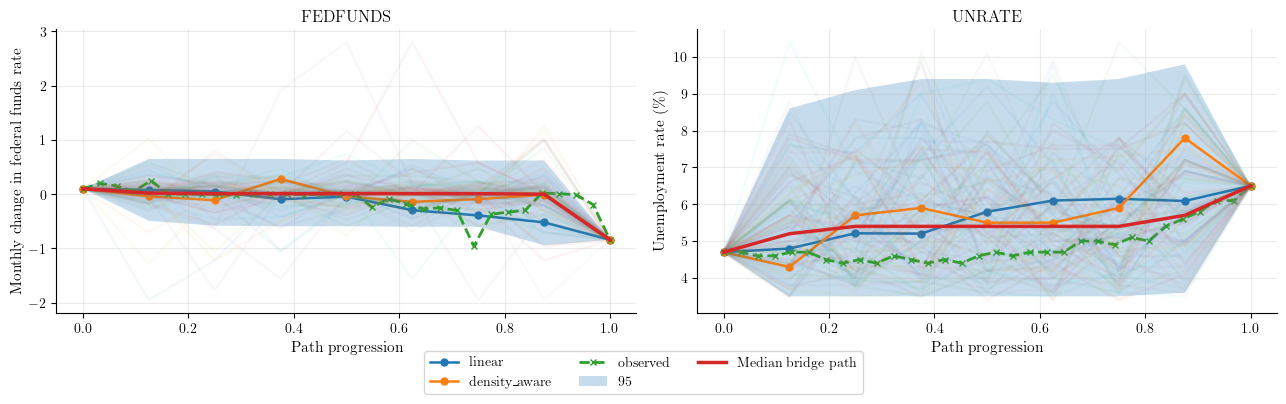

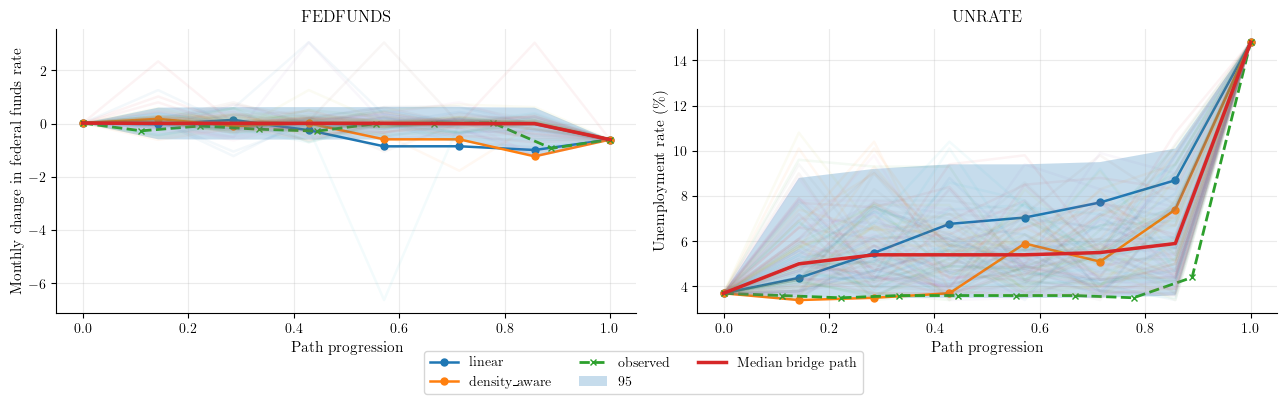

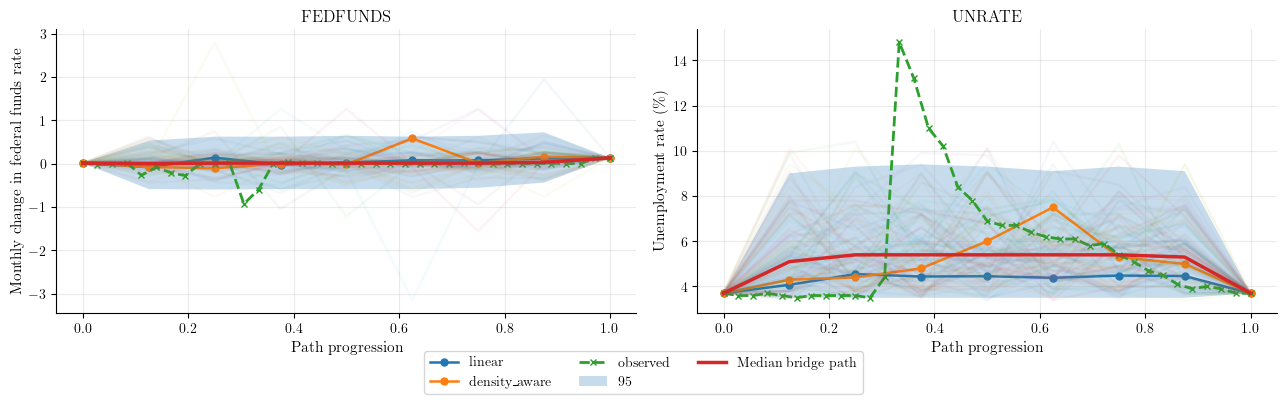

In [167]:
# Change the confidence interval via this variable
quantile = 95

for event, selected_vars in event_variables.items():
    event_records = [rec for rec in lifted_path_records if rec["event"] == event]

    selected_idxs = [variables.get_loc(v) for v in selected_vars]
    n_vars = len(selected_vars); n_rows = 1
    n_cols = int(np.ceil(n_vars / n_rows))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=ps.FIG_DOUBLE_WD, squeeze=False)
    axes_flat = axes.flatten()

    for path in event_records:
        path_type = path["path_type"]
        if path_type not in ["linear", "density_aware", "observed", "density_aware_bridge_paths"]:
            continue

        lifted_path = path["Z_lift_real"]
        x = np.linspace(0, 1, lifted_path.shape[-2])

        for i, var_idx in enumerate(selected_idxs):
            ax = axes_flat[i]
            if path_type == "observed":
                ax.plot(x, lifted_path[:, var_idx], marker="x", linestyle="--", label=path_type, lw=2)
            elif path_type == "density_aware_bridge_paths":
                plot_bridge_paths(lifted_path, var_idx, quantile=quantile, plot_paths=True, steps=x, ax=ax)
            else:
                ax.plot(x, lifted_path[:, var_idx], marker="o", label=path_type.replace(r"$\\beta=1.5$", ""))

            ax.set_title(selected_vars[i].replace("&", "\\&"), fontweight='bold')
            ax.set_xlabel("Path progression")
            ax.set_ylabel(transformed_variable_ylabels.get(selected_vars[i], selected_vars[i]))

    for j in range(n_vars, len(axes_flat)):
        fig.delaxes(axes_flat[j])

    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02))

    # event_rename = event.replace("->", r"$\\rightarrow$")
    # plt.suptitle(rf'Selected lifted macro variables: {event_rename}', fontsize=14, fontweight="bold")

    plt.tight_layout(); plt.subplots_adjust(bottom=0.20)
    event_label = event.split(" ")[-1]
    plt.savefig(f"./figures/lifted_macro_vars_{event_label}.pdf")
    plt.show()

Interesting to see the FEDFUNDS confidence interval so narrow for the 1982 recession but very wide for Monetary tightening

I think that the distributions of the paths are basically identical for each path in the interior. The paths just jump from the benign node to the dense region where it hangs about in for a while and then it jumps off to the non-dense stress point. To remedy this, we could change the density estimate to have a less peaked density field; more nodes of a similar density. Although this might just result in the distributions being wider and still the same. 

We could also maybe look at the construction of the transition matrix to be more local which might encourage more directed paths between endpoints. However, the distributions don't currently capture the complete picture when comparing to the real path because the real paths sometimes dip out of the confidence intervals. They dip out of the confidence intervals more than the confidence interval would expect, so there must be something wrong.

# END OF ANALYSIS 
# ==============================================================
### Rest of notebook was for creating the Markov bridge figures for the presentation

#### Calculate the mean value of the generated paths in diffusion space

In [ ]:
bridge = compute_markov_bridge(P, start_idx, end_idx, T)
bridge_paths = sample_markov_bridges(P, bridge["h"], start_idx, end_idx, n_paths=10_000, seed=42)
bridge_marginals = bridge["marginals"]
Z_bridge_quantile = Z[bridge_paths]
Z_bridge_real = Z_real[bridge_paths]

In [ ]:
def plot_bridge_step_2d(Psi, bridge_marginals, t, dims=(0, 1), density_path=None, save=None):
    if density_path is not None and not 0 <= t < len(density_path): raise ValueError("t is outside the path.")
    p = bridge_marginals[t]; x, y = dims
    fig = plt.figure(figsize=(ps.FIG_SINGLE_SQ[0]+1.5, ps.FIG_SINGLE_SQ[1]))
    ax = fig.add_subplot()
    relative_prob = np.sqrt(p / (p.max() + 1e-300))
    sc = ax.scatter(Psi[:, x], Psi[:, y], c=p, s=8 + 40 * relative_prob, cmap="viridis", alpha=0.85)

    if density_path:
        G = Psi[density_path]
        ax.plot(G[:, x], G[:, y], linewidth=3, label="Density-aware path", c="r")
        ax.scatter(G[t, x], G[t, y], s=130, marker="X", c="g", label=f"Density path, step {t}")

    ax.set_xlabel(r"$\psi_1$"); ax.set_ylabel(r"$\psi_2$")
    ax.set_title(f"Density-aware Markov-bridge distribution at step {t}")
    fig.colorbar(sc, ax=ax, pad=0.1, label="Bridge probability", format=ticker.FormatStrFormatter('%.4f'))
    if density_path: ax.legend()
    if save:
        if save.split(".")[-1] == "pdf":
            plt.savefig(save)
        else:
            plt.savefig(save, dpi=300, bbox_inches="tight")
    plt.show()


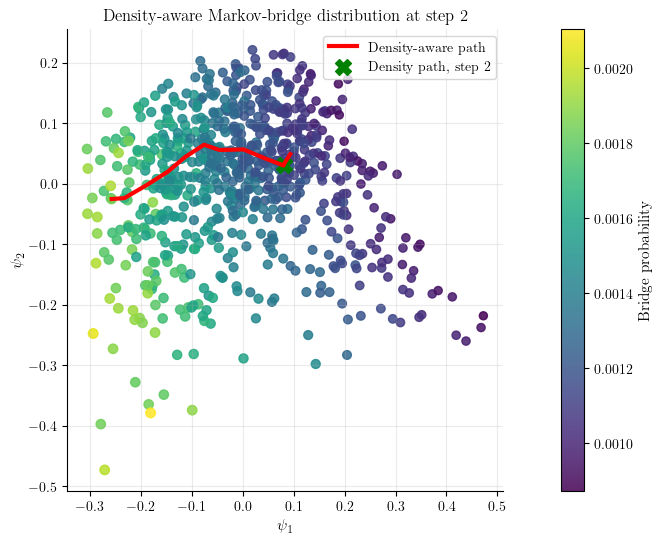

In [ ]:
i = 2
plot_bridge_step_2d(Psi, bridge_marginals, density_path=density_path, t=i)# , save=f"./presentation_figures/markov_bridge_82_t{i}.png")

In [ ]:
avgs = []

for event, (s, e) in pairs.items():
    bridge_da = compute_markov_bridge(P_da, s, e, T)
    bridge_marginals_da = bridge_da["marginals"]
    bridge_paths_da = sample_markov_bridges(P_da, bridge_da["h"], s, e, n_paths=10_000, seed=42)

    avg_bridge_exact = bridge_marginals_da @ Psi

    avgs.append(avg_bridge_exact)

In [211]:
beta = 10
density_weight = np.exp(-beta * V)
P_da = P * density_weight[None, :] 
q_da = P_da.sum(axis=1)
P_da = P_da / q_da[:, None]

In [216]:
event, (s, e) = list(pairs.items())[0]

bridge_da = compute_markov_bridge(P_da, s, e, T)
bridge_marginals_da = bridge_da["marginals"]
bridge_paths_da = sample_markov_bridges(P_da, bridge_da["h"], s, e, n_paths=10_000, seed=42)

avg_bridge_exact = bridge_marginals_da @ Psi

density_path = graph_path(A_dist_sym, beta=80, V=V, start=s, end=e)


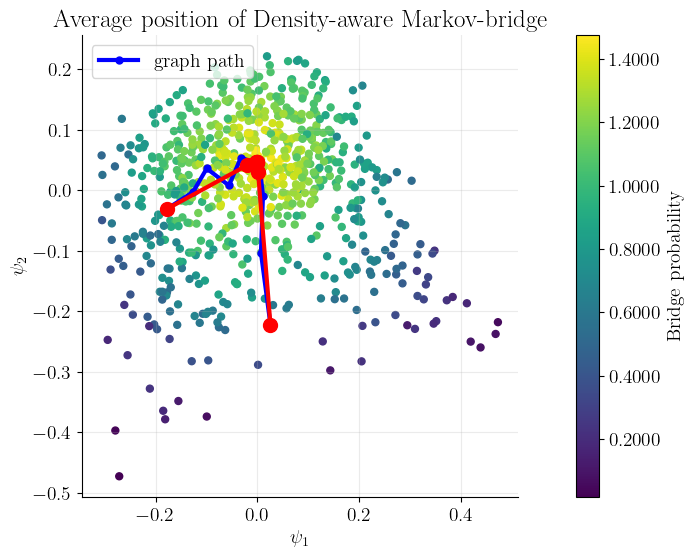

In [217]:
fig = plt.figure(figsize=(ps.FIG_SINGLE_SQ[0]+1.5, ps.FIG_SINGLE_SQ[1]))
ax = fig.add_subplot()

sc = ax.scatter(Psi[:, 0], Psi[:, 1], c=rho, cmap="viridis")
ax.plot(Psi[density_path, 0], Psi[density_path, 1], c="b", marker="o", linewidth=3, label="graph path")
ax.plot(avg_bridge_exact[:, 0], avg_bridge_exact[:, 1], marker="o", ms=10, c="r", linewidth=3)#, label=f"exact bridge mean {list(pairs.keys())[i]}")

ax.set_xlabel(r"$\psi_1$"); ax.set_ylabel(r"$\psi_2$")
ax.set_title(f"Average position of Density-aware Markov-bridge")
fig.colorbar(sc, ax=ax, pad=0.1, label="Bridge probability", format=ticker.FormatStrFormatter('%.4f'))
plt.legend(loc="upper left")
# plt.savefig("./presentation_figures/da_mb_graph_path_82_THEOTHER.png", dpi=300, bbox_inches="tight")
plt.show()

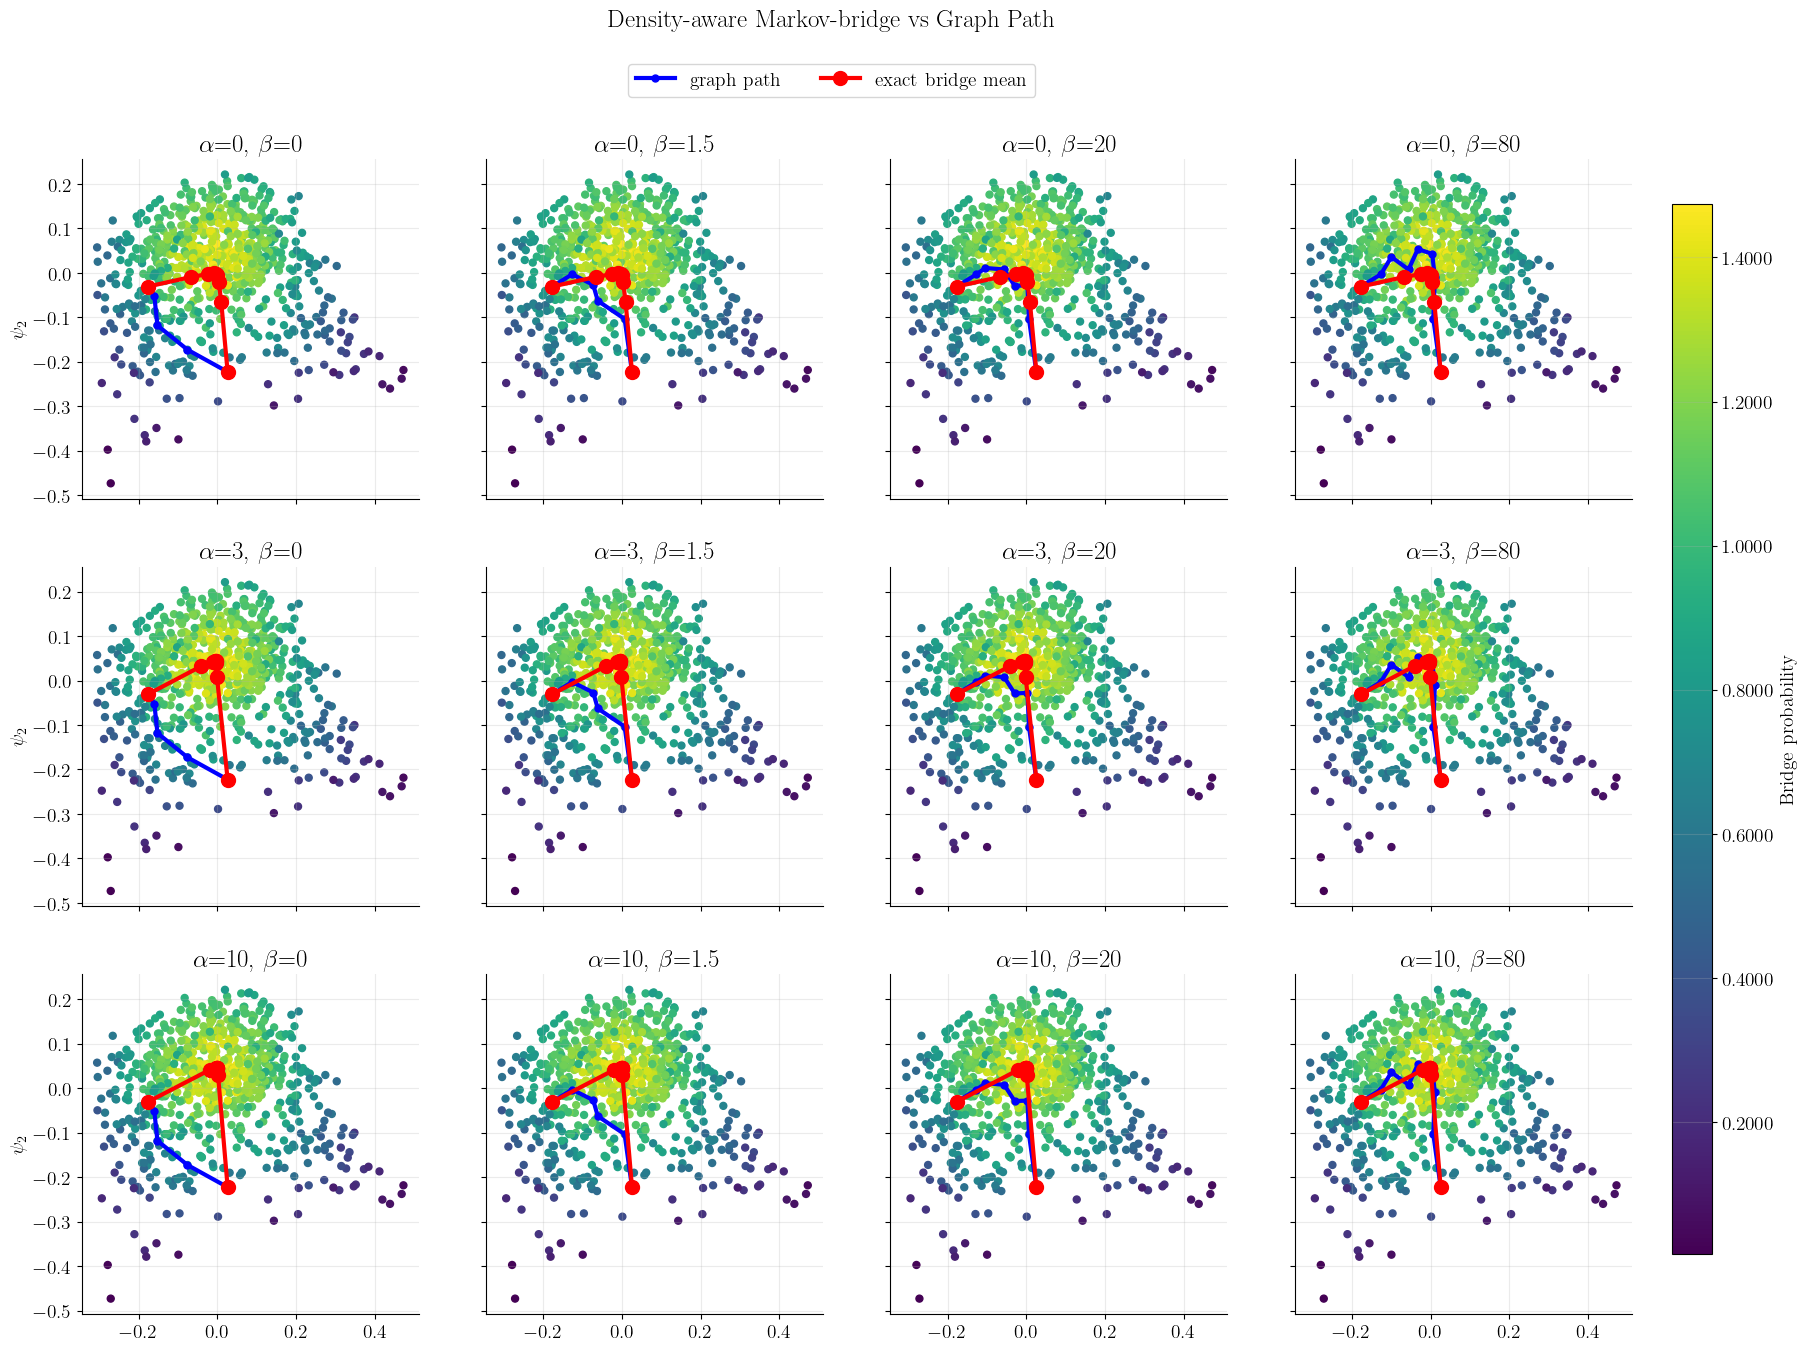

In [222]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Parameter grids
alpha_values = [0, 3, 10]
beta_values = [0, 1.5, 20, 80]

# Assuming P, V, Psi, rho, A_dist_sym, pairs, and T are already defined
event, (s, e) = list(pairs.items())[0]

# Set up the 4x4 figure
fig, axes = plt.subplots(3, 4, figsize=(20, 15), sharex=True, sharey=True)

for i, alpha in enumerate(alpha_values):
    # 1. Compute alpha-dependent Markov Bridge (Rows)
    density_weight = np.exp(-alpha * V)
    P_da = P * density_weight[None, :] 
    q_da = P_da.sum(axis=1)
    P_da = P_da / q_da[:, None]
    
    bridge_da = compute_markov_bridge(P_da, s, e, T)
    bridge_marginals_da = bridge_da["marginals"]
    
    # Optional: Omitted sampling here to save compute time since it isn't plotted
    # bridge_paths_da = sample_markov_bridges(P_da, bridge_da["h"], s, e, n_paths=10_000, seed=42)
    
    avg_bridge_exact = bridge_marginals_da @ Psi
    
    for j, beta in enumerate(beta_values):
        # 2. Compute beta-dependent Graph Path (Columns)
        density_path = graph_path(A_dist_sym, beta=beta, V=V, start=s, end=e)
        
        ax = axes[i, j]
        
        # Plot background scatter
        sc = ax.scatter(Psi[:, 0], Psi[:, 1], c=rho, cmap="viridis")
        
        # Plot graph path
        # Only add labels for the first plot to avoid cluttering a master legend
        label_gp = "graph path" if (i == 0 and j == 0) else None
        ax.plot(Psi[density_path, 0], Psi[density_path, 1], c="b", marker="o", 
                linewidth=3, label=label_gp)
        
        # Plot exact bridge mean
        label_bm = "exact bridge mean" if (i == 0 and j == 0) else None
        ax.plot(avg_bridge_exact[:, 0], avg_bridge_exact[:, 1], marker="o", ms=10, 
                c="r", linewidth=3, label=label_bm)
        
        # Formatting
        ax.set_title(f"$\\alpha$={alpha}, $\\beta$={beta}")
        
        if i == 3:
            ax.set_xlabel(r"$\psi_1$")
        if j == 0:
            ax.set_ylabel(r"$\psi_2$")

# Add a single colorbar for the entire figure to save space
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(sc, cax=cbar_ax, label="Bridge probability", format=ticker.FormatStrFormatter('%.4f'))

# Add a single master legend
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.95), ncol=2, fontsize=14)

plt.suptitle("Density-aware Markov-bridge vs Graph Path", fontsize=18, y=0.98)
plt.subplots_adjust(right=0.9) # Make room for the colorbar
plt.savefig("./figures/markov_diffusion_paths_grid.pdf")
plt.show()

In [ ]:
from matplotlib import animation, ticker
import numpy as np
import matplotlib.pyplot as plt

def animate_bridge_2d(Psi, bridge_marginals, dims=(0, 1), density_path=None,
                      save="./presentation_figures/density_aware_markov_bridge82.mp4",
                      fps=8, dpi=200, hold_frames=0):

    bridge_marginals = np.asarray(bridge_marginals)
    T = len(bridge_marginals) - 1
    x, y = dims

    if density_path is not None and len(density_path) < T + 1:
        raise ValueError("density_path must contain at least T+1 points.")

    fig = plt.figure(figsize=(ps.FIG_SINGLE_SQ[0] + 1.5, ps.FIG_SINGLE_SQ[1]))
    ax = fig.add_subplot()

    p = bridge_marginals[0]
    relative_prob = np.sqrt(p / (p.max() + 1e-300))

    sc = ax.scatter(
        Psi[:, x], Psi[:, y],
        c=p, s=8 + 40 * relative_prob,
        cmap="viridis", vmin=0, vmax=p.max(),
        alpha=0.85
    )

    moving_point = None

    if density_path is not None:
        G = Psi[density_path]
        ax.plot(G[:, x], G[:, y], linewidth=3, label="Density-aware path", c="r")
        moving_point = ax.scatter(
            [G[0, x]], [G[0, y]],
            s=130, marker="X", c="g",
            label="Density-aware path"
        )
        ax.legend()

    ax.set_xlabel(r"$\psi_1$")
    ax.set_ylabel(r"$\psi_2$")
    title = ax.set_title("Density-aware Markov-bridge distribution at step 0")

    cbar = fig.colorbar(
        sc, ax=ax, pad=0.1,
        label="Bridge probability",
        format=ticker.FormatStrFormatter("%.4f")
    )

    def update(t):
        p = bridge_marginals[t]
        relative_prob = np.sqrt(p / (p.max() + 1e-300))

        sc.set_array(p)
        sc.set_sizes(8 + 40 * relative_prob)
        sc.set_clim(0, p.max())
        cbar.update_normal(sc)

        if moving_point is not None:
            moving_point.set_offsets([[G[t, x], G[t, y]]])

        title.set_text(f"Density-aware Markov-bridge distribution at step {t}")

        return [sc, title] + ([moving_point] if moving_point is not None else [])

    frames = list(range(T + 1))

    # Optional pause on first and last frames
    if hold_frames > 0:
        frames = [0] * hold_frames + frames + [T] * hold_frames

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=frames,
        interval=1000 / fps,
        blit=False,
        repeat=True
    )

    if save is not None:
        if save.lower().endswith(".gif"):
            ani.save(save, writer=animation.PillowWriter(fps=fps), dpi=dpi)
        else:
            writer = animation.FFMpegWriter(fps=fps, bitrate=3000)
            ani.save(save, writer=writer, dpi=dpi)

    plt.close(fig)
    return ani

In [ ]:
ani = animate_bridge_2d(Psi, bridge_marginals_da, 
                        save="./presentation_figures/markov_bridge_density_aware82.mp4", 
                        fps=1, dpi=200, hold_frames=1)

In [ ]:
for i in range(T+1):
    plot_bridge_step_2d(Psi, bridge_marginals_da, t=i, save=f"./presentation_figures/density_aware_markov_bridge82_t{i}.png")

#### Plots for all paths

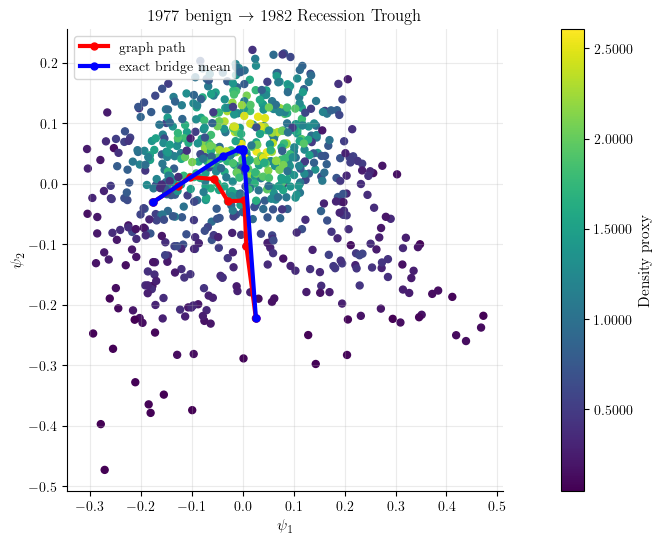

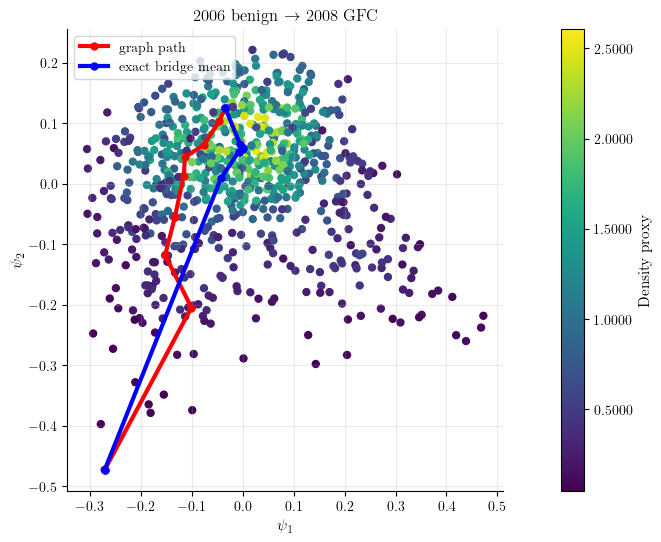

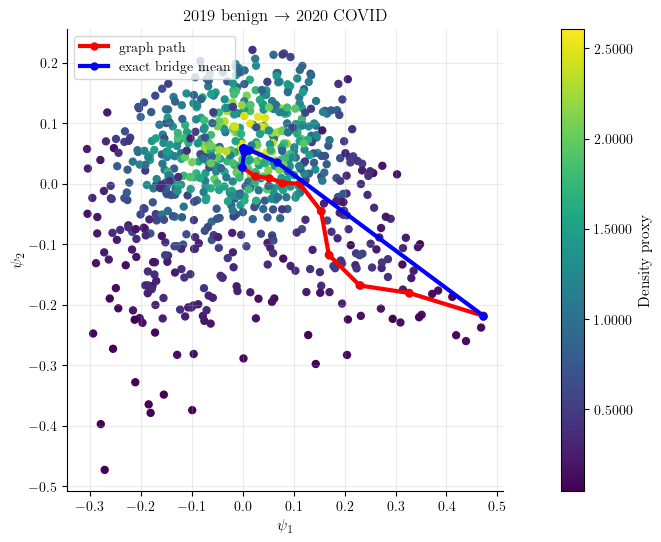

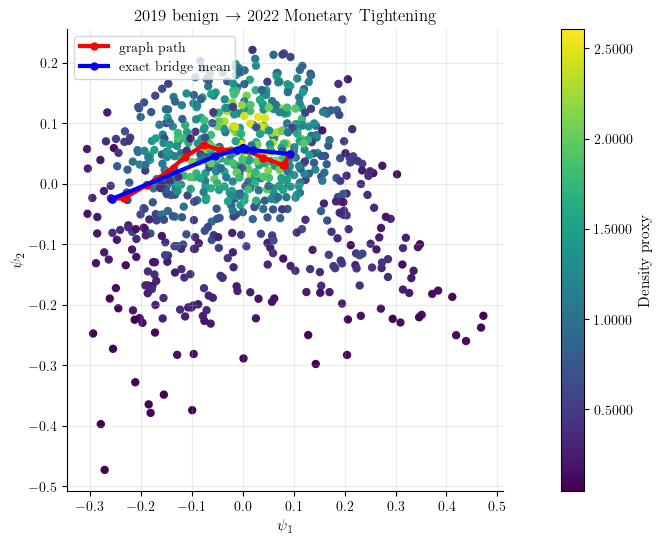

In [125]:
for event, (s, e) in pairs.items():

    density_path = graph_path(A_dist_sym, BETA, V, s, e)
    T = len(density_path) - 1

    beta = 1.5
    density_weight = np.exp(-beta * V)
    P_da = P * density_weight[None, :] 
    q_da = P_da.sum(axis=1)
    P_da = P_da / q_da[:, None]

    bridge_da = compute_markov_bridge(P_da, s, e, T)
    bridge_marginals_da = bridge_da["marginals"]
    bridge_paths_da = sample_markov_bridges(P_da, bridge_da["h"], s, e, n_paths=10_000, seed=42)

    avg_bridge_exact = bridge_marginals_da @ Psi

    fig = plt.figure(figsize=(ps.FIG_SINGLE_SQ[0]+1.5, ps.FIG_SINGLE_SQ[1]))
    ax = fig.add_subplot()

    sc = ax.scatter(Psi[:, 0], Psi[:, 1], c=rho, cmap="viridis")
    ax.plot(Psi[density_path, 0], Psi[density_path, 1], c="r", marker="o", linewidth=3, label="graph path")
    ax.plot(avg_bridge_exact[:, 0], avg_bridge_exact[:, 1], c="b", marker="o", linewidth=3, label="exact bridge mean")

    event_name = event.replace("->", r"$\rightarrow$")

    ax.set_xlabel(r"$\psi_1$"); ax.set_ylabel(r"$\psi_2$")
    ax.set_title(event_name)
    fig.colorbar(sc, ax=ax, pad=0.1, label="Density proxy", format=ticker.FormatStrFormatter('%.4f'))
    plt.legend(loc="upper left")
    plt.savefig(f"./presentation_figures/da_mb_graph_path_{event.split(' ')[-1]}.png", dpi=300, bbox_inches="tight")
    plt.show()


# OTHER METRICS TO EXPLORE LATER ---------------------------------------

In [ ]:
def plot_bridge_step(Psi, bridge_marginals, density_path, t, dims=(0, 1, 2)):
    """
    Plot the exact Markov-bridge distribution at one step.

    Calculations can use all diffusion dimensions.
    dims controls only the 3D visualisation.
    """

    Psi = np.asarray(Psi)
    density_path = np.asarray(density_path)

    if not 0 <= t < len(density_path):
        raise ValueError("t is outside the path.")

    p = bridge_marginals[t]

    x, y, z = dims

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")

    # Background manifold
    ax.scatter(Psi[:, x], Psi[:, y], Psi[:, z], s=8, alpha=0.12)

    # Relative marker sizes make low probabilities visible
    relative_prob = np.sqrt(p / (p.max() + 1e-300))

    sc = ax.scatter(Psi[:, x], Psi[:, y], Psi[:, z], c=p, s=8 + 80 * relative_prob, cmap="viridis", alpha=0.85)

    # Deterministic density-aware path
    G = Psi[density_path]
    ax.plot(G[:, x], G[:, y], G[:, z], linewidth=2.5, label="Density-aware path")

    # Point on deterministic path corresponding to this t
    ax.scatter(G[t, x], G[t, y], G[t, z], s=130, marker="X", label=f"Density path, step {t}")
    ax.set_xlabel(r"$\psi_1$"); ax.set_ylabel(r"$\psi_2$"); ax.set_zlabel(r"$\psi_3$")
    ax.set_title(f"Markov-bridge distribution at step {t}")
    fig.colorbar(sc, ax=ax, pad=0.1, label="Bridge probability")
    ax.legend(); plt.show()


In [61]:
def path_bridge_support(Psi, bridge_marginals, density_path, k=15):
    """
    Compare each deterministic path point with the bridge
    distribution at the corresponding step.
    """

    Psi = np.asarray(Psi, dtype=float)
    density_path = np.asarray(density_path, dtype=int)

    T = bridge_marginals.shape[0] - 1

    if len(density_path) != T + 1:
        raise ValueError("density_path and bridge must have the same number of points.")

    k = min(k, len(Psi))

    nn = NearestNeighbors(n_neighbors=k).fit(Psi)

    neighbourhoods = nn.kneighbors(Psi[density_path], return_distance=False)

    rows = []

    for t, node in enumerate(density_path):

        p = bridge_marginals[t]

        # Probability of exact deterministic path node
        exact_probability = p[node]

        # Probability in its k-nearest-node neighbourhood
        neighbourhood_mass = p[neighbourhoods[t]].sum()

        # Another useful measure:
        # expected diffusion distance between the bridge
        # and the deterministic path point
        distances = np.linalg.norm(Psi - Psi[node], axis=1)

        expected_distance = np.sum(p * distances)

        rows.append({"step": t, "path_node": node, 
                     "exact_node_probability": exact_probability, 
                     f"knn_{k}_probability": neighbourhood_mass, 
                     "expected_diffusion_distance": expected_distance})

    return pd.DataFrame(rows)



idx_graph = graph_path(A_dist_sym, 1.5, V, start_idx, end_idx)
T = len(idx_graph) -1

alpha = 2
Pda = P * np.exp(-alpha*V)[None, :]
qda = np.sum(Pda, axis=1)
Pda = Pda / qda[:, None]


bridge = compute_markov_bridge(Pda, start_idx, end_idx, T)
bridge_marginals = bridge["marginals"]


support = path_bridge_support(Psi, bridge_marginals, idx_graph, k=15)
display(support)

,step,path_node,exact_node_probability,knn_15_probability,expected_diffusion_distance
0,0,658,1.000000,1.000000,0.000000
1,1,734,0.006983,0.081137,0.127521
2,2,378,0.004955,0.063154,0.136591
3,3,631,0.006209,0.071000,0.123590
4,4,382,0.006698,0.079001,0.116651
5,5,374,0.005057,0.061493,0.129224
6,6,112,0.004397,0.055898,0.140249
7,7,494,0.003739,0.047287,0.157931
8,8,489,0.002816,0.037039,0.184340
9,9,279,0.001855,0.025858,0.217447


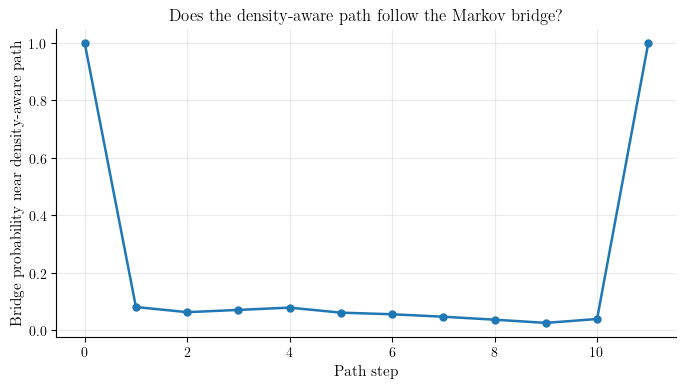

In [62]:
k_column = "knn_15_probability"

plt.figure(figsize=(8, 4))

plt.plot(support["step"],support[k_column], marker="o")

plt.xlabel("Path step")
plt.ylabel("Bridge probability near density-aware path")
plt.title("Does the density-aware path follow the Markov bridge?")

plt.grid(alpha=0.25)
plt.show()